# 실습 5-2 : SHAP Value

#### **<실습 내용>**

1. SHAP - 회귀 모델 (Regression)
- TreeExplainer를 사용한 SHAP 분석
- Summary Plot / Force Plot / Dependence Plot

3. SHAP - 분류 모델 (Classification)
- TreeExplainer를 사용한 SHAP 분석
- Summary Plot / Force Plot / Dependence Plot

## 분석 준비

### 주요 라이브러리 호출

In [1]:
!uv add shap

Resolved 392 packages in 5.12s
Prepared 2 packages in 832ms
Installed 2 packages in 388ms
 + shap==0.52.0
 + slicer==0.0.8


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, f1_score
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

import shap

d:\autornd\SK Autonomous R&D\AutoRnDEnv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## 1) SHAP - 회귀 모델

In [3]:
# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

### 1-1) 데이터 및 모델 준비

In [4]:
Regression = pd.read_csv("dataset/day5-2_reg_data.csv")
Regression

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X50,X51,X52,X53,X54,X55,X56,X57,X58,y
0,0.40420,0.39615,0.34470,0.39535,0.44180,0.38830,0.36245,0.34480,0.32475,0.38020,...,0.39200,0.34985,0.37980,0.42355,0.38990,0.40890,0.41720,0.37765,0.36190,48.272178
1,0.47115,0.35280,0.29120,0.30190,0.54875,0.40430,0.42125,0.32620,0.35280,0.43115,...,0.32080,0.35185,0.35570,0.38400,0.44375,0.25945,0.55030,0.43205,0.31395,49.767621
2,0.31185,0.35220,0.41940,0.38370,0.30015,0.32555,0.39790,0.44730,0.55625,0.60885,...,0.36105,0.36230,0.30455,0.26945,0.49770,0.37425,0.27800,0.41980,0.37620,45.512356
3,0.43900,0.38300,0.38830,0.33920,0.40740,0.40650,0.45455,0.40565,0.41915,0.33565,...,0.33715,0.46605,0.45040,0.37150,0.37625,0.28595,0.45195,0.40570,0.39885,55.646432
4,0.38005,0.42835,0.53105,0.39145,0.31755,0.40365,0.33230,0.48530,0.44295,0.37615,...,0.43555,0.30330,0.26910,0.35155,0.42230,0.43660,0.35875,0.43605,0.46260,47.703096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,0.40675,0.37110,0.29385,0.37125,0.43345,0.32380,0.40365,0.32200,0.35655,0.50940,...,0.31965,0.32385,0.37480,0.37240,0.46065,0.33660,0.40075,0.37875,0.30040,44.683854
237,0.37940,0.36660,0.39205,0.42100,0.37860,0.42690,0.39580,0.39240,0.39080,0.35705,...,0.43260,0.40485,0.36410,0.45070,0.37270,0.45270,0.36685,0.39055,0.40395,47.907255
238,0.35150,0.35285,0.24365,0.40190,0.50055,0.37125,0.36820,0.28830,0.34130,0.48590,...,0.38300,0.38705,0.41305,0.40750,0.39510,0.40895,0.40825,0.35865,0.30240,45.900853
239,0.30580,0.46180,0.50870,0.43220,0.38695,0.43260,0.24155,0.45805,0.38565,0.29875,...,0.51305,0.36490,0.35580,0.36160,0.31170,0.53040,0.36960,0.38475,0.49090,51.418961


In [5]:
X_reg = Regression.drop(["y"], axis=1) # 입력변수
Y_reg = Regression["y"] # 출력변수

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(X_reg, Y_reg, test_size=0.2, random_state=42) # 학습/테스트 데이터 분할

In [6]:
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=0) # RandomForest로 모델 학습
rf_reg.fit(X_train_reg, Y_train_reg)
Y_pred_reg = rf_reg.predict(X_test_reg)
get_regscore(Y_test_reg, Y_pred_reg)

MSE       : 6.592
RMSE      : 2.568
MAE       : 1.991
R-squared : 0.558


### 2-2) SHAP 분석

In [7]:
# rf_reg 모델을 해석하기 위한 SHAP 설명자 생성
explainer_reg = shap.TreeExplainer(rf_reg)

# 학습 데이터(X_train_reg)에 대한 SHAP value 계산
# 각 feature가 예측값에 기여하는 정도를 나타냄
shap_values_reg = explainer_reg.shap_values(X_train_reg)

#### Summary Plot (Bar)
- 막대가 길수록 예측에 영향을 많이 주는 변수라는 뜻임

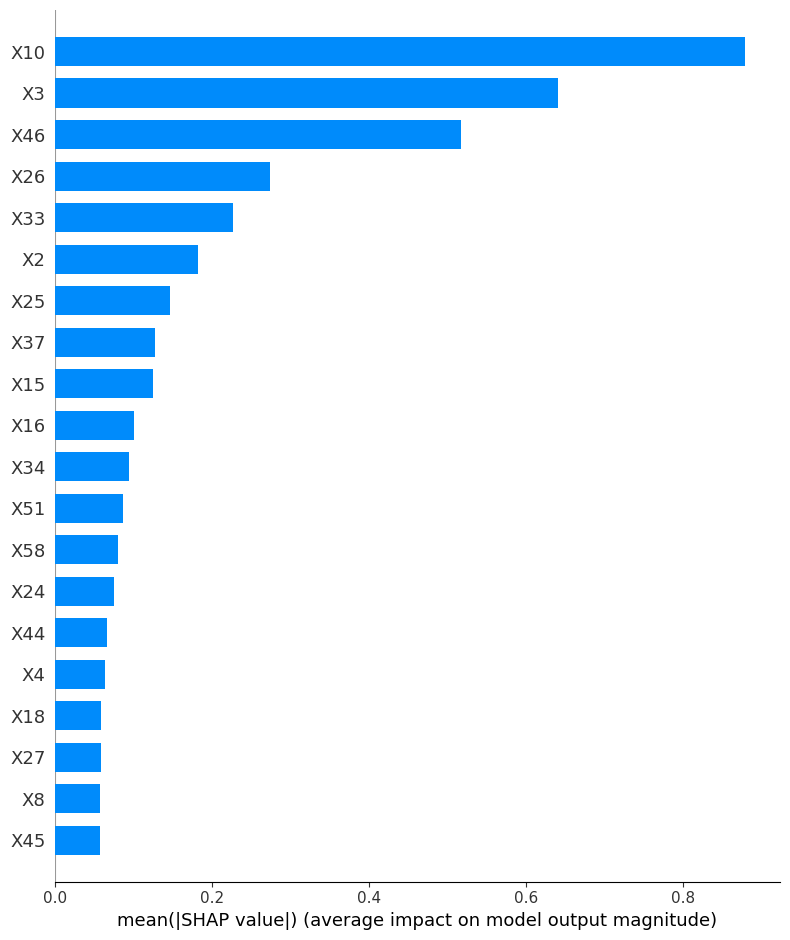

In [8]:
shap.summary_plot(shap_values_reg, X_train_reg, plot_type='bar')

#### Summary Plot (Scatter)
- 오른쪽에 점이 몰려있으면 예측값을 올리는 변수, 왼쪽에 몰려있으면 예측값을 낮추는 변수임

> - 빨간색: 높은 변수 값
> - 파란색: 낮은 변수 값

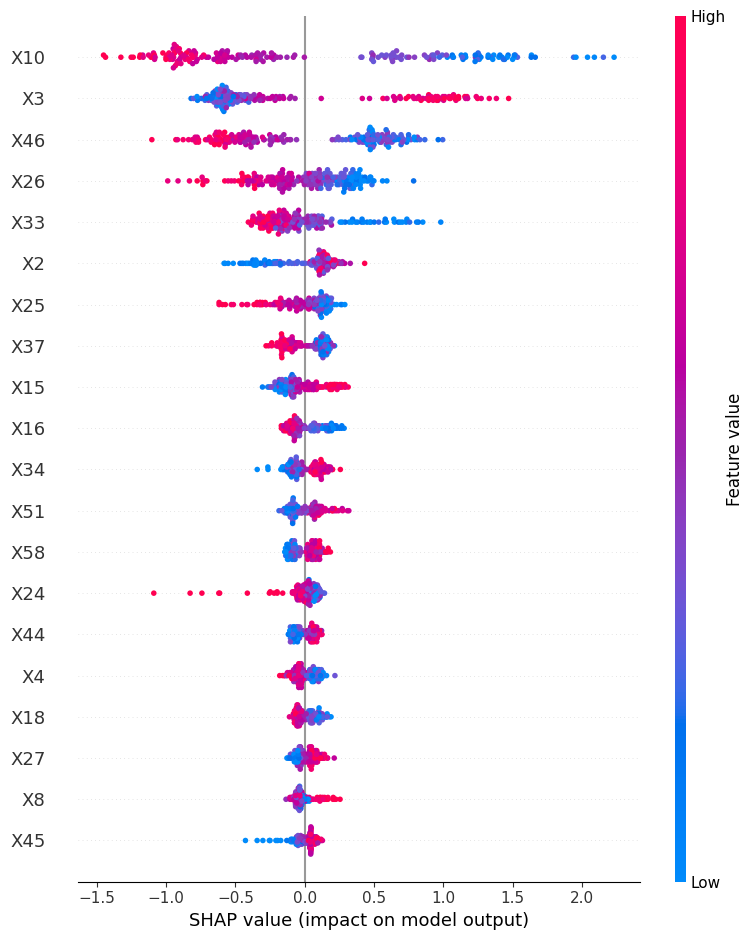

In [9]:
shap.summary_plot(shap_values_reg, X_train_reg)

#### Force Plot (개별 데이터)
- 데이터 하나를 뽑아서 어떤 변수가 예측값을 올렸고 내렸는지 화살표로 보여주는 그래프임

In [10]:
base_value_reg = explainer_reg.expected_value
print(base_value_reg)

[49.74460342]


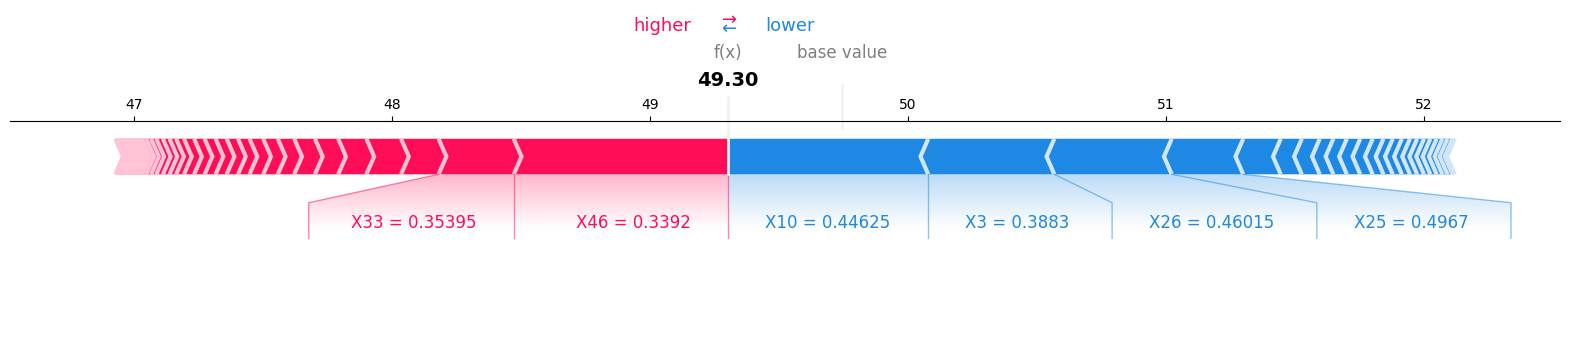

In [11]:
# 첫 번째 데이터(index 0)의 예측 결과를 force plot으로 시각화
# expected_value: 전체 데이터의 평균 예측값 (기준선)
# shap_values_reg[0]: 이 데이터의 각 feature별 SHAP value 
# X_train_reg.iloc[0]: 실제 feature 값들 (그래프에 표시용)

shap.force_plot(
    explainer_reg.expected_value,
    shap_values_reg[0],
    X_train_reg.iloc[0],
    matplotlib=True
)

#### Dependence Plot
- 변수 값이 변할 때 SHAP 값(영향력)이 같이 어떻게 움직이는지 보여주는 그래프임

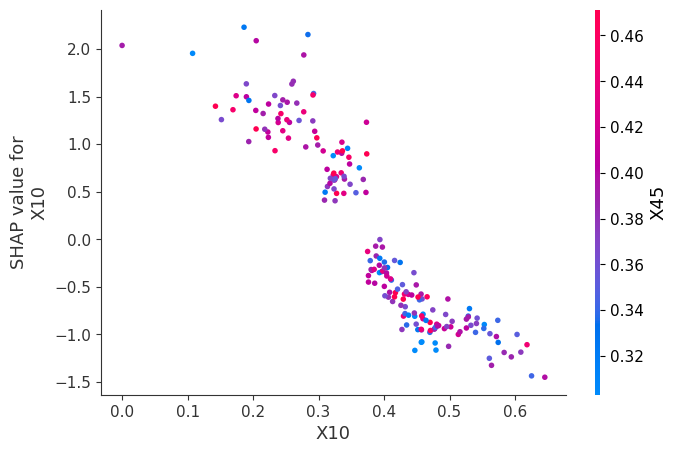

In [12]:
# "X10" feature 값에 따라 SHAP value가 어떻게 변하는지 시각화
# x축: X10의 실제 값, y축: X10의 SHAP value (예측에 미친 영향)
# 자동으로 X10과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X10",
    shap_values_reg,
    X_train_reg
)

---

## 3) SHAP - 분류 모델

In [13]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

### 3-1) 데이터 및 모델 준비

In [14]:
Classification = pd.read_csv("dataset/day5-2_cls_data.csv")
Classification

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X466,X467,X468,X469,X470,X471,X472,X473,X474,Y
0,0.457896,0.530189,0.276976,0.359864,0.193059,0.322190,0.706897,0.553781,0.653894,0.375204,...,0.246376,0.711806,0.008532,0.013672,0.008467,0.402240,0.238811,0.274876,0.210238,-1
1,0.607100,0.341478,0.518992,0.395300,0.042071,0.469654,0.750000,0.542031,0.447466,0.189233,...,0.523785,0.760417,0.030930,0.033203,0.029759,0.210356,0.309339,0.328358,0.439175,-1
2,0.360781,0.369653,0.341039,0.021697,0.181737,0.528684,0.491379,0.516722,0.300371,0.376835,...,0.185769,0.659722,0.005333,0.003906,0.005311,0.381877,0.208171,0.208955,0.155761,-1
3,0.460910,0.413500,0.535685,0.302794,0.242326,0.408966,0.646552,0.561615,0.415328,0.313214,...,0.246376,0.000000,1.000000,1.000000,1.000000,0.381877,0.208171,0.208955,0.155761,-1
4,0.263068,0.279821,0.535685,0.302794,0.242326,0.408966,0.646552,0.638747,0.660074,0.520392,...,0.110711,0.517361,0.023677,0.022461,0.023447,0.608414,0.212062,0.268657,0.092827,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,0.360022,0.396033,0.382803,0.070771,0.143308,0.920884,0.586207,0.636336,0.337454,0.432300,...,0.000000,0.597222,0.016212,0.013672,0.015997,0.045307,0.147860,0.171642,0.000000,1
250,0.508628,0.437628,0.192378,0.061866,0.168425,0.481919,0.715517,0.270563,0.407911,0.336052,...,0.132582,0.975694,0.017065,0.015625,0.016114,0.543689,0.227626,0.320896,0.111165,1
251,0.275930,0.364365,0.302236,0.376615,0.485135,0.627270,0.594828,0.435673,0.420272,0.367047,...,0.246376,0.586806,0.008532,0.015625,0.008613,0.343042,0.151751,0.164179,0.143012,1
252,0.785179,0.271804,0.400189,0.457851,0.229526,0.244320,0.396552,0.875565,0.110012,0.337684,...,0.221768,0.767361,0.024317,0.019531,0.023461,0.509709,0.398833,0.440299,0.185945,1


In [15]:
X_cls = Classification.drop(["Y"], axis=1) # 입력변수
Y_cls = Classification["Y"] # 출력변수

X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls, test_size=0.2, random_state=123, stratify=Y_cls)

rf_cls = RandomForestClassifier(n_estimators=100, random_state=0)
rf_cls.fit(X_train_cls, Y_train_cls)
Y_pred_cls = rf_cls.predict(X_test_cls)
get_classscore(Y_test_cls, Y_pred_cls)

Accuracy  : 0.863
Precision : 0.938
Recall    : 0.714
F1-score  : 0.811

혼동행렬
[[29  1]
 [ 6 15]]


### 3-2) SHAP 분석

In [16]:
explainer_cls = shap.TreeExplainer(rf_cls)
shap_values_cls = explainer_cls.shap_values(X_train_cls)

#### Summary Plot (Bar)

> 분류 모델의 경우 `shap_values_cls`는 (샘플 수, 변수 수, 클래스 수) 형태의 3차원 배열임
> - `shap_values_cls[:, :, 0]`: 클래스 -1에 대한 SHAP
> - `shap_values_cls[:, :, 1]`: 클래스 1에 대한 SHAP

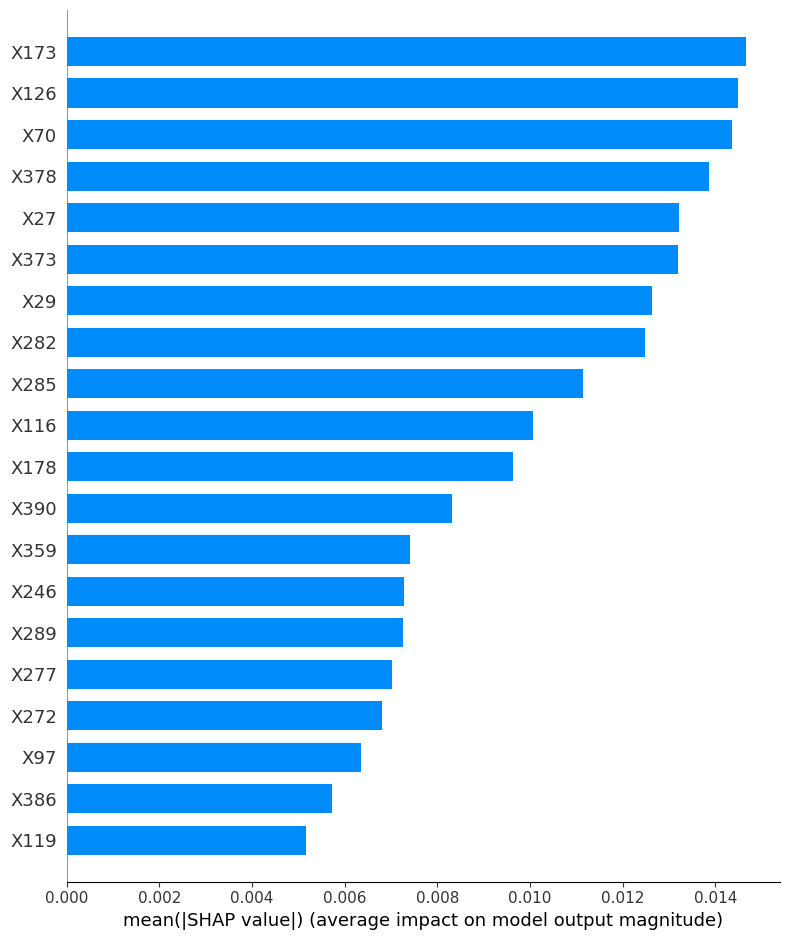

In [17]:
shap.summary_plot(shap_values_cls[:, :, 0], X_train_cls, plot_type='bar')  # 클래스 -1 기준

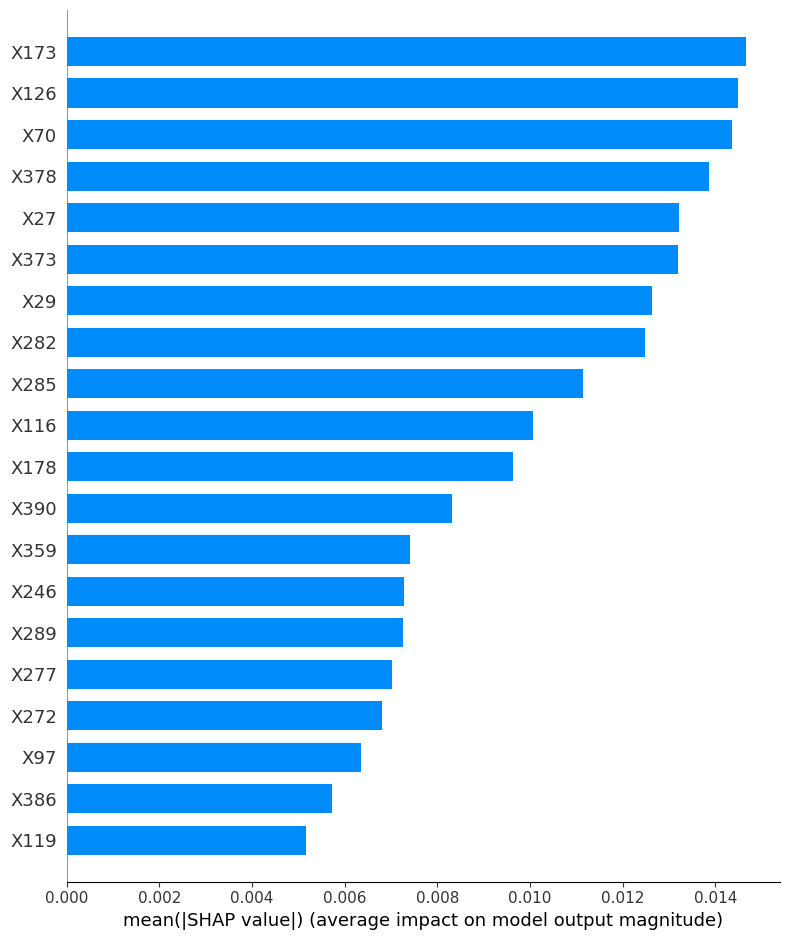

In [18]:
shap.summary_plot(shap_values_cls[:, :, 1], X_train_cls, plot_type='bar')  # 클래스 1 기준

#### Summary Plot (Scatter) - 클래스별

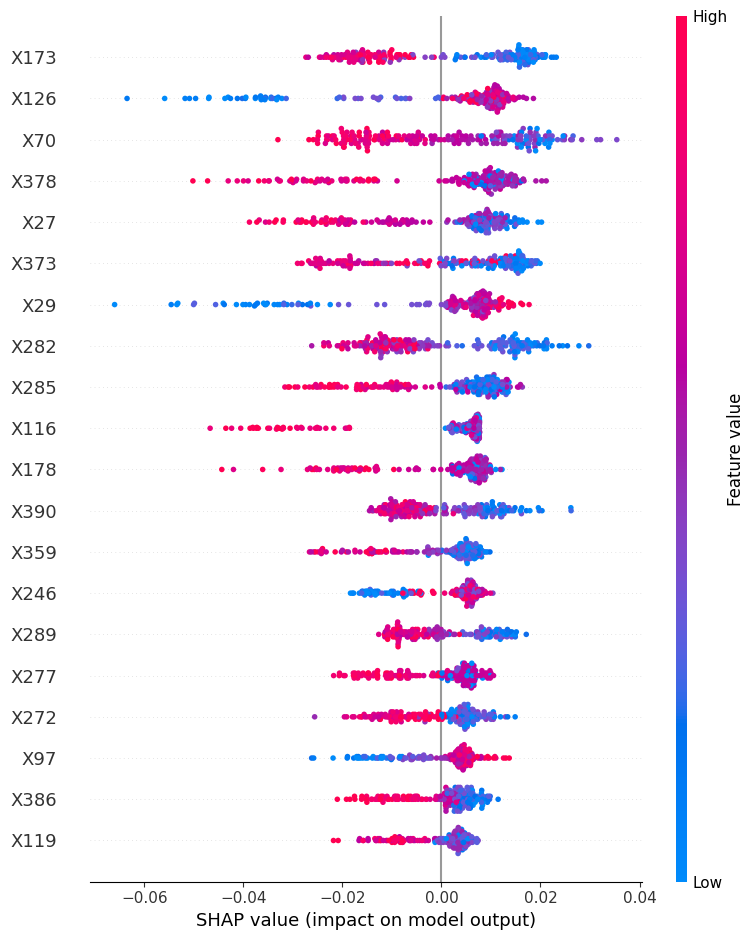

In [19]:
shap.summary_plot(shap_values_cls[:, :, 0], X_train_cls) # 클래스 = -1

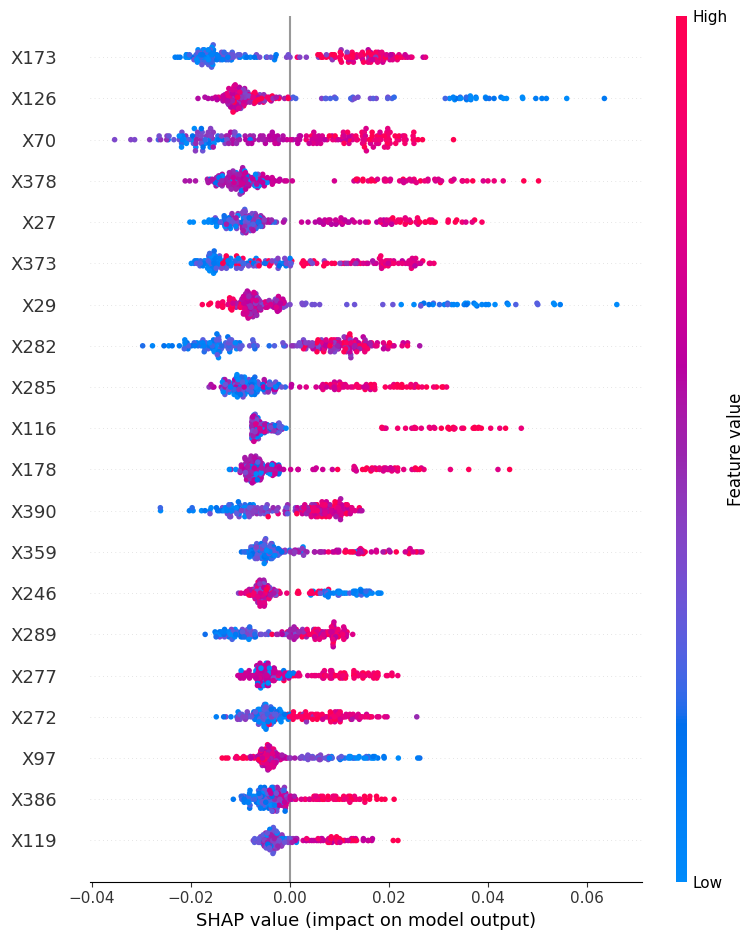

In [20]:
# 변수 중요도 순서는 같은데 부호가 반대 방향임

shap.summary_plot(shap_values_cls[:, :, 1], X_train_cls) # 클래스 = 1

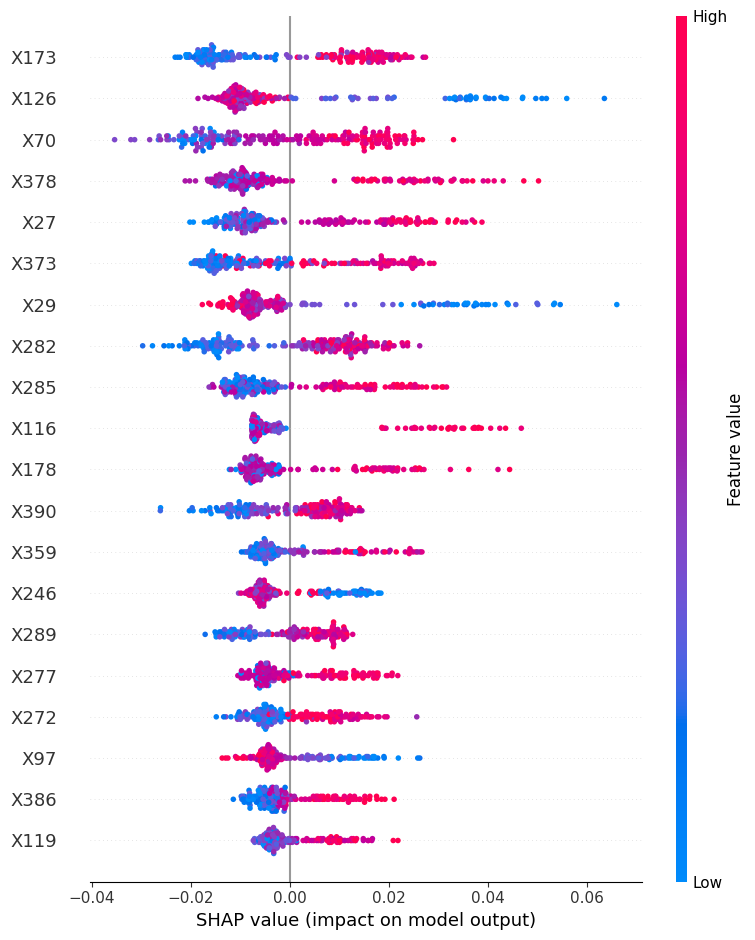

In [21]:
shap.summary_plot(shap_values_cls[:, :, 1], X_train_cls)

#### Force Plot (개별 데이터)

In [22]:
# 15번 데이터의 실제(정답) 클래스 확인
Y_train_cls.iloc[15]

np.int64(-1)

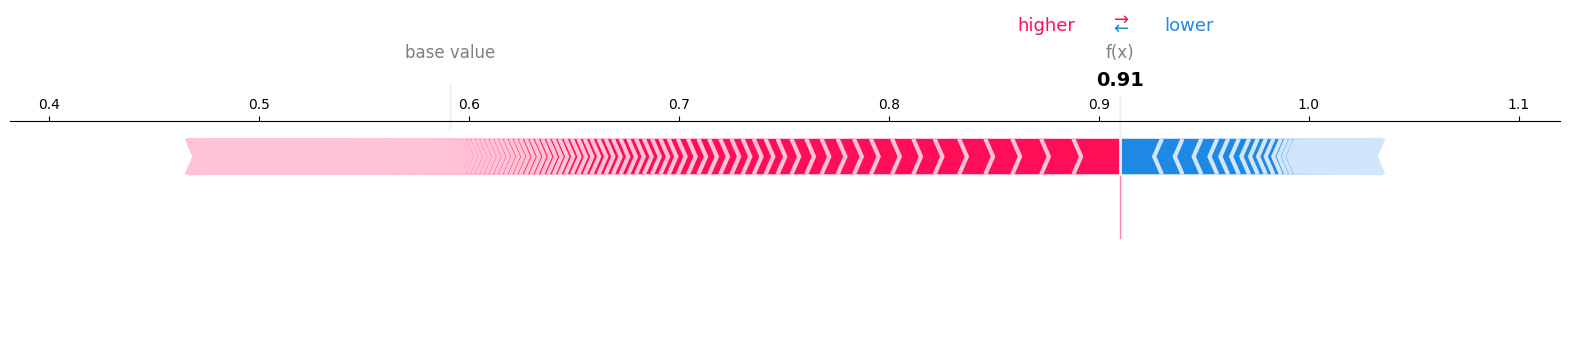

In [23]:
# 15번 데이터를 클래스 -1로 예측하는 데 각 feature가 어떻게 기여했는지 시각화

# expected_value[0]: 클래스 -1에 대한 기준값(base value)
# shap_values_cls[15, :, 0]: 15번 데이터의, 클래스 -1에 대한 각 feature별 SHAP value
# X_train_cls.iloc[15]: 15번 데이터의 실제 feature 값들 

shap.force_plot(
    explainer_cls.expected_value[0],
    shap_values_cls[15, :, 0],
    X_train_cls.iloc[15],
    matplotlib=True
)

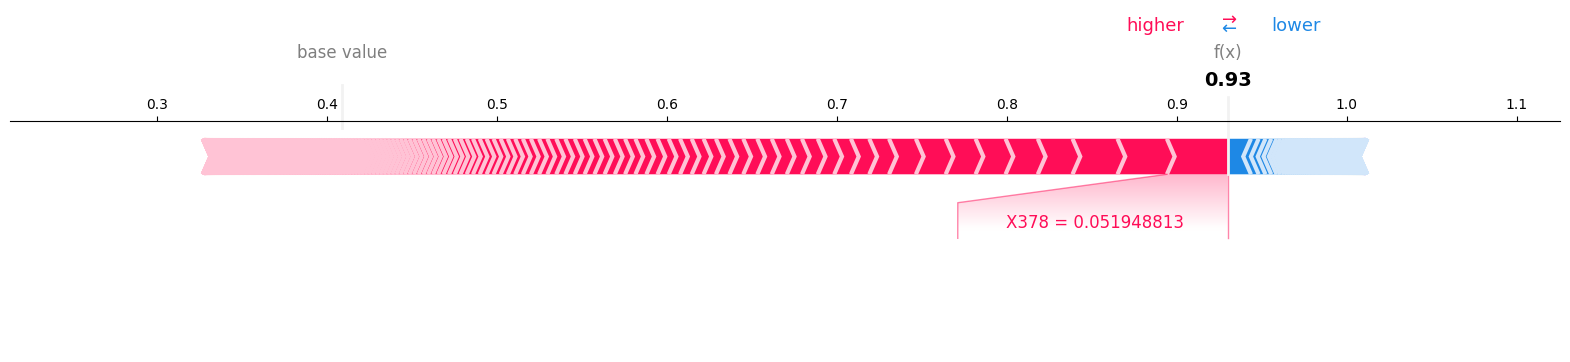

In [24]:
# 40번 데이터를 클래스 1로 예측하는 데 각 feature가 어떻게 기여했는지 시각화

# expected_value[1]: 클래스 1에 대한 기준값(base value)
# shap_values_cls[40, :, 1]: 40번 데이터의, 클래스 1에 대한 각 feature별 SHAP value
# X_train_cls.iloc[40]: 40번 데이터의 실제 feature 값들

shap.force_plot(
    explainer_cls.expected_value[1],
    shap_values_cls[40, :, 1],
    X_train_cls.iloc[40],
    matplotlib=True
)

#### Dependence Plot

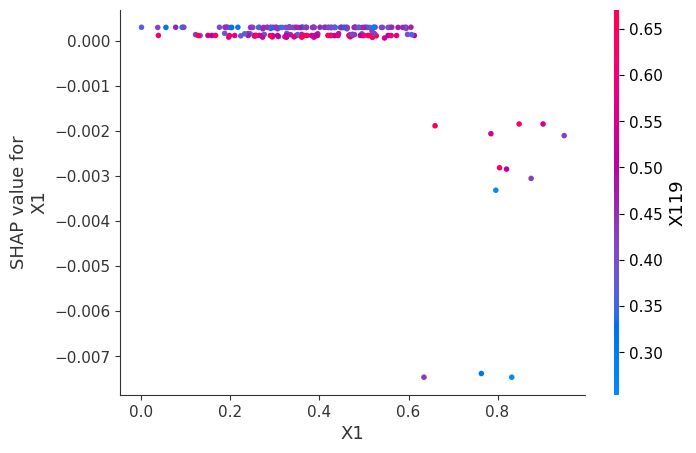

In [25]:
# "X1" feature 값에 따라, 클래스 -1에 대한 SHAP value가 어떻게 변하는지 시각화
# x축: X1의 실제 값, y축: X1의 클래스 -1 기준 SHAP value (예측에 미친 영향)
# 자동으로 X1과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X1",
    shap_values_cls[:, :, 0],
    X_train_cls
)

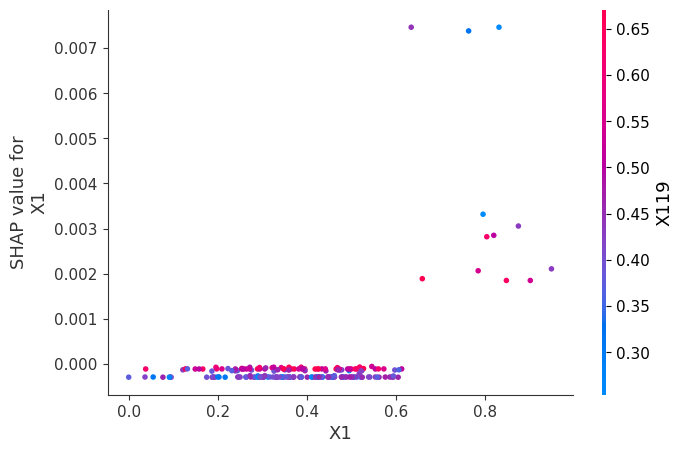

In [26]:
# "X1" feature 값에 따라, 클래스 1에 대한 SHAP value가 어떻게 변하는지 시각화
# x축: X1의 실제 값, y축: X1의 클래스 1 기준 SHAP value (예측에 미친 영향)
# 자동으로 X1과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X1",
    shap_values_cls[:, :, 1],
    X_train_cls
)

---

## 4) Vibe Coding 실습

**[과제 1]** 

지수는 Random Forest의 Feature Importance와 SHAP Value가 모두 변수의 중요도를 설명하는 방법이라는 것을 배웠습니다.

AI와 함께 Random Forest (회귀/분류)의 feature_importances_와 SHAP Summary Plot 결과를 비교해 보세요.

두 방법에서 중요하게 평가된 변수가 얼마나 비슷한지 확인하고 순위가 다른 변수는 왜 차이가 발생했는지 AI와 토의하여 해석해 보세요.

회귀 모델 — RF Importance vs SHAP (Summary Plot bar 기준)


,변수,RF 중요도,SHAP 중요도,RF 순위,SHAP 순위,순위 차이
0,X10,0.193025,0.879149,1,1,0
1,X3,0.141376,0.640705,2,2,0
2,X46,0.089514,0.516354,3,3,0
3,X26,0.050647,0.273539,4,4,0
4,X33,0.034804,0.226753,5,5,0
5,X2,0.033480,0.181888,6,6,0
6,X25,0.028282,0.146616,7,7,0
7,X37,0.026450,0.127244,8,8,0
8,X15,0.022193,0.124085,9,9,0
9,X58,0.015704,0.079550,10,13,3



[회귀] 상위 10개 변수 유사도
  Spearman 순위 상관계수: 0.950 (p=6.13e-30)
  상위 10개 교집합: 9/10개 → ['X10', 'X15', 'X2', 'X25', 'X26', 'X3', 'X33', 'X37', 'X46']
  순위 차이가 큰 변수 TOP 5:


,변수,RF 순위,SHAP 순위,순위 차이
29,X4,30,16,14
31,X47,32,45,13
26,X44,27,15,12
36,X29,37,48,11
18,X14,19,29,10


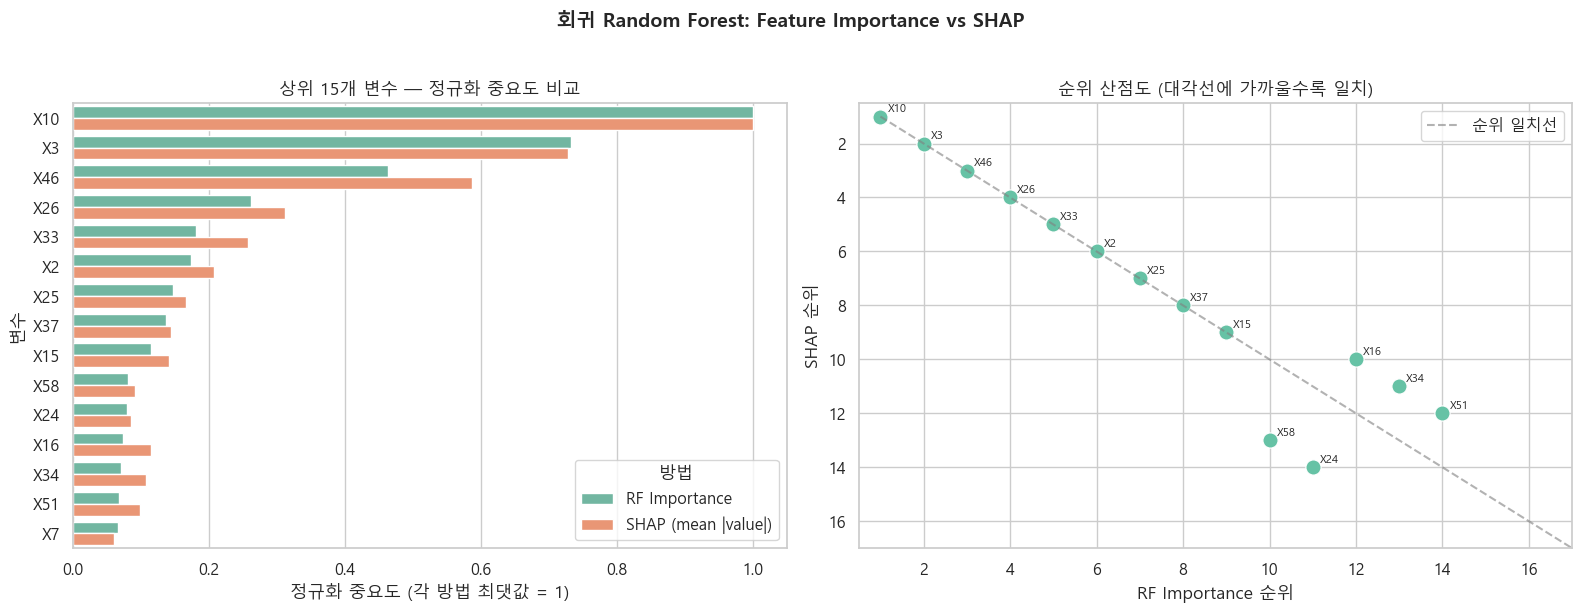

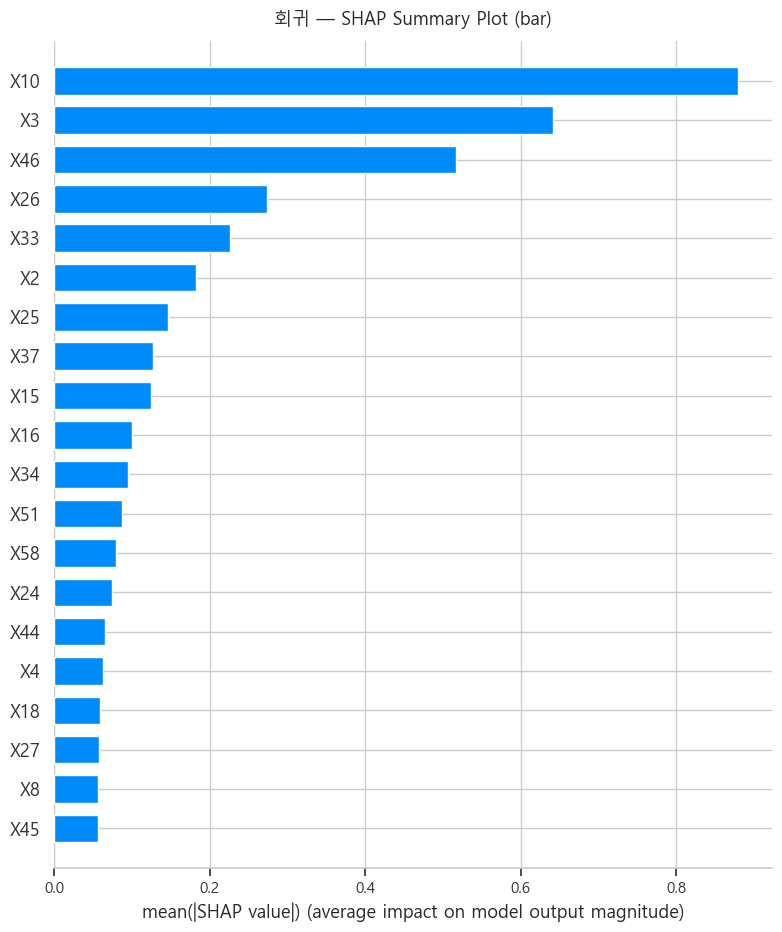

분류 모델 (클래스 -1) — RF Importance vs SHAP


,변수,RF 중요도,SHAP 중요도,RF 순위,SHAP 순위,순위 차이
0,X373,0.024285,0.013201,1,6,5
1,X126,0.022421,0.014494,2,2,0
2,X70,0.021257,0.014354,3,3,0
3,X29,0.021031,0.012635,4,7,3
4,X378,0.019221,0.013869,5,4,1
5,X27,0.018447,0.013207,6,5,1
6,X282,0.017265,0.012474,7,8,1
7,X173,0.016975,0.014662,8,1,7
8,X277,0.014767,0.007017,9,16,7
9,X285,0.014313,0.011140,10,9,1



[분류 (클래스 -1)] 상위 10개 변수 유사도
  Spearman 순위 상관계수: 0.963 (p=4.18e-272)
  상위 10개 교집합: 9/10개 → ['X126', 'X173', 'X27', 'X282', 'X285', 'X29', 'X373', 'X378', 'X70']
  순위 차이가 큰 변수 TOP 5:


,변수,RF 순위,SHAP 순위,순위 차이
398,X396,399,228,171
144,X181,145,305,160
310,X47,311,157,154
126,X194,127,265,138
293,X233,294,172,122


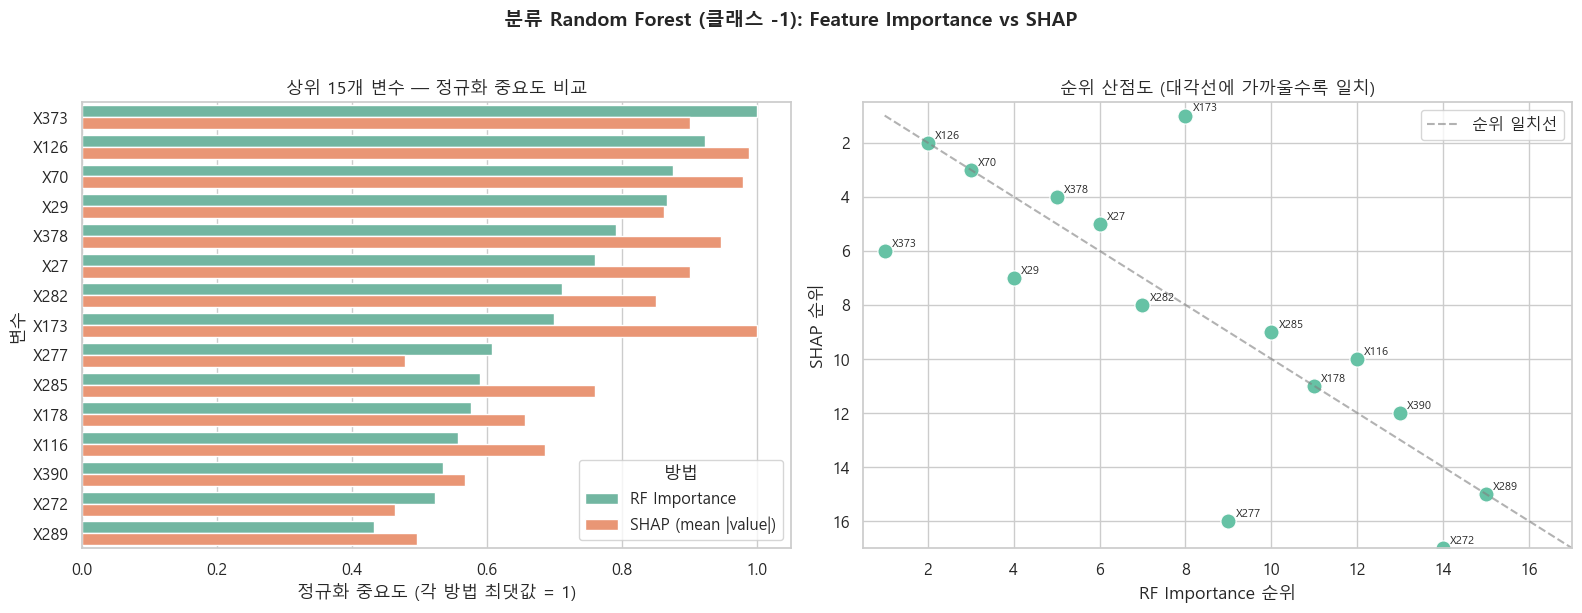

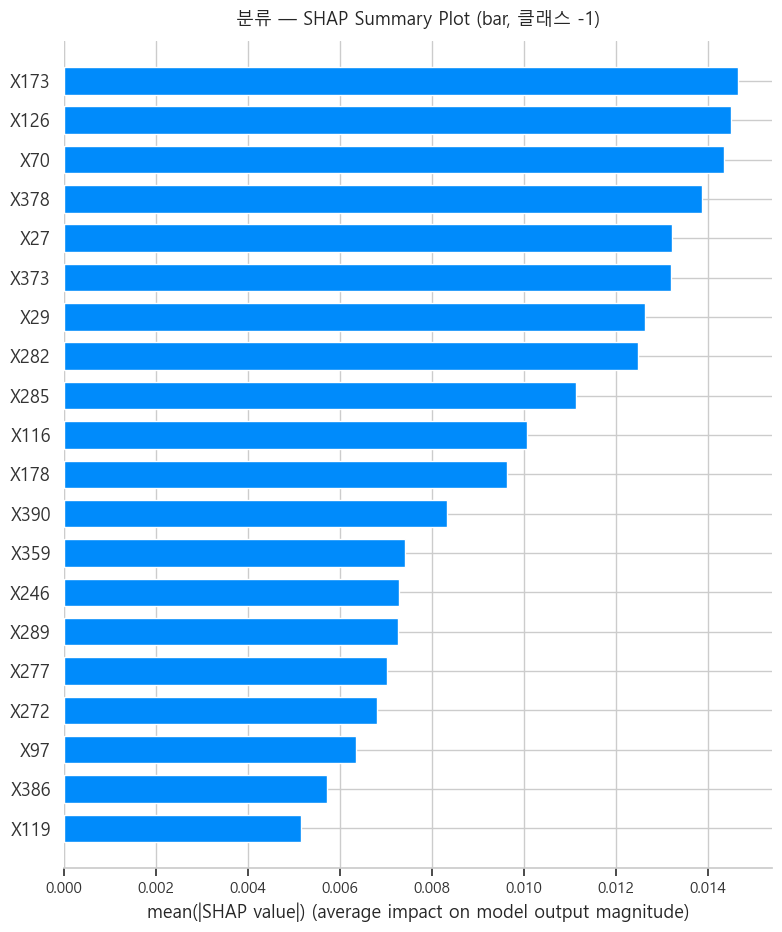

분류 모델 (클래스 1) — RF Importance vs SHAP


,변수,RF 중요도,SHAP 중요도,RF 순위,SHAP 순위,순위 차이
0,X373,0.024285,0.013201,1,6,5
1,X126,0.022421,0.014494,2,2,0
2,X70,0.021257,0.014354,3,3,0
3,X29,0.021031,0.012635,4,7,3
4,X378,0.019221,0.013869,5,4,1
5,X27,0.018447,0.013207,6,5,1
6,X282,0.017265,0.012474,7,8,1
7,X173,0.016975,0.014662,8,1,7
8,X277,0.014767,0.007017,9,16,7
9,X285,0.014313,0.011140,10,9,1



[분류 (클래스 1)] 상위 10개 변수 유사도
  Spearman 순위 상관계수: 0.963 (p=4.18e-272)
  상위 10개 교집합: 9/10개 → ['X126', 'X173', 'X27', 'X282', 'X285', 'X29', 'X373', 'X378', 'X70']
  순위 차이가 큰 변수 TOP 5:


,변수,RF 순위,SHAP 순위,순위 차이
398,X396,399,228,171
144,X181,145,305,160
310,X47,311,157,154
126,X194,127,265,138
293,X233,294,172,122


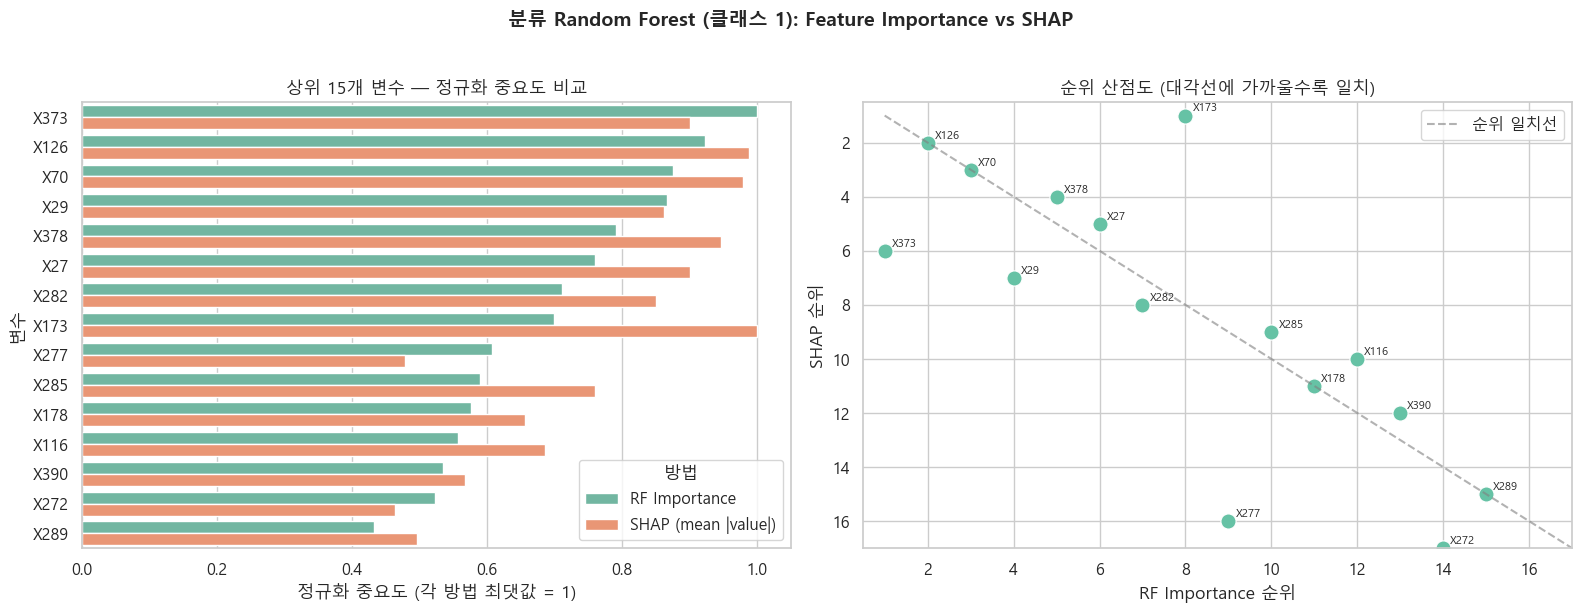

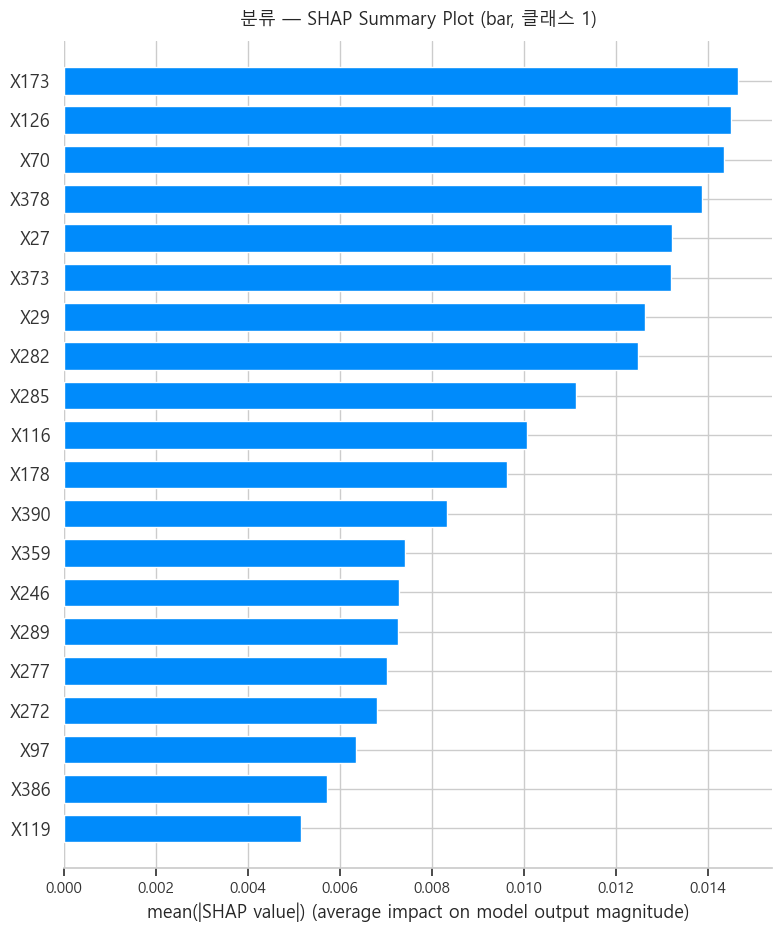

In [27]:
import seaborn as sns
import matplotlib.font_manager as fm
from scipy.stats import spearmanr

def setup_korean_font():
    """matplotlib/seaborn 한글 폰트 적용. sns.set_theme() 호출 후 재호출 필요."""
    _korean_fonts = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Gulim"]
    _available = {f.name for f in fm.fontManager.ttflist}
    for _font in _korean_fonts:
        if _font in _available:
            plt.rcParams["font.family"] = _font
            break
    plt.rcParams["axes.unicode_minus"] = False

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
setup_korean_font()

TOP_N = 15


def build_importance_df(model, shap_values, feature_names):
    """RF feature_importances_와 mean(|SHAP|) 비교용 DataFrame 생성"""
    rf_imp = model.feature_importances_
    shap_imp = np.abs(shap_values).mean(axis=0)

    df = pd.DataFrame({
        "변수": feature_names,
        "RF 중요도": rf_imp,
        "SHAP 중요도": shap_imp,
    })
    df["RF 순위"] = df["RF 중요도"].rank(ascending=False, method="min").astype(int)
    df["SHAP 순위"] = df["SHAP 중요도"].rank(ascending=False, method="min").astype(int)
    df["순위 차이"] = (df["RF 순위"] - df["SHAP 순위"]).abs()
    return df.sort_values("RF 순위").reset_index(drop=True)


def summarize_similarity(df, label, top_k=10):
    """두 방법의 순위 유사도 요약"""
    rho, pval = spearmanr(df["RF 순위"], df["SHAP 순위"])
    top_rf = set(df.nsmallest(top_k, "RF 순위")["변수"])
    top_shap = set(df.nsmallest(top_k, "SHAP 순위")["변수"])
    overlap = top_rf & top_shap
    print(f"\n[{label}] 상위 {top_k}개 변수 유사도")
    print(f"  Spearman 순위 상관계수: {rho:.3f} (p={pval:.2e})")
    print(f"  상위 {top_k}개 교집합: {len(overlap)}/{top_k}개 → {sorted(overlap)}")
    big_gap = df.nlargest(5, "순위 차이")[["변수", "RF 순위", "SHAP 순위", "순위 차이"]]
    print(f"  순위 차이가 큰 변수 TOP 5:")
    display(big_gap)


def plot_importance_comparison(df, title, top_n=TOP_N):
    """RF vs SHAP 중요도 비교 시각화 (seaborn)"""
    setup_korean_font()
    top = df.nsmallest(top_n, "RF 순위").copy()
    top["RF 정규화"] = top["RF 중요도"] / top["RF 중요도"].max()
    top["SHAP 정규화"] = top["SHAP 중요도"] / top["SHAP 중요도"].max()

    melted = top.melt(
        id_vars=["변수", "RF 순위", "SHAP 순위"],
        value_vars=["RF 정규화", "SHAP 정규화"],
        var_name="방법", value_name="정규화 중요도",
    )
    melted["방법"] = melted["방법"].map({"RF 정규화": "RF Importance", "SHAP 정규화": "SHAP (mean |value|)"})

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)

    sns.barplot(
        data=melted, y="변수", x="정규화 중요도", hue="방법",
        ax=axes[0], orient="h",
    )
    axes[0].set_title(f"상위 {top_n}개 변수 — 정규화 중요도 비교")
    axes[0].set_xlabel("정규화 중요도 (각 방법 최댓값 = 1)")
    axes[0].legend(title="방법", loc="lower right")

    sns.scatterplot(
        data=top, x="RF 순위", y="SHAP 순위", s=120, ax=axes[1], color=sns.color_palette("Set2")[0],
    )
    for _, row in top.iterrows():
        axes[1].annotate(
            row["변수"], (row["RF 순위"], row["SHAP 순위"]),
            textcoords="offset points", xytext=(5, 3), fontsize=8,
        )
    lim = top_n + 2
    axes[1].plot([1, lim], [1, lim], "--", color="gray", alpha=0.6, label="순위 일치선")
    axes[1].set_xlim(0.5, lim)
    axes[1].set_ylim(lim, 0.5)
    axes[1].set_xlabel("RF Importance 순위")
    axes[1].set_ylabel("SHAP 순위")
    axes[1].set_title("순위 산점도 (대각선에 가까울수록 일치)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# ===== 1) 회귀 모델 비교 =====
comp_reg = build_importance_df(rf_reg, shap_values_reg, X_reg.columns)
print("=" * 60)
print("회귀 모델 — RF Importance vs SHAP (Summary Plot bar 기준)")
display(comp_reg.head(TOP_N))
summarize_similarity(comp_reg, "회귀")
plot_importance_comparison(comp_reg, "회귀 Random Forest: Feature Importance vs SHAP")

# SHAP Summary Plot (bar) — 노트북과 동일한 기준
setup_korean_font()
shap.summary_plot(shap_values_reg, X_train_reg, plot_type="bar", show=False)
plt.title("회귀 — SHAP Summary Plot (bar)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# ===== 2) 분류 모델 비교 =====
for cls_idx, cls_name in [(0, "클래스 -1"), (1, "클래스 1")]:
    shap_cls = shap_values_cls[:, :, cls_idx]
    comp_cls = build_importance_df(rf_cls, shap_cls, X_cls.columns)
    print("=" * 60)
    print(f"분류 모델 ({cls_name}) — RF Importance vs SHAP")
    display(comp_cls.head(TOP_N))
    summarize_similarity(comp_cls, f"분류 ({cls_name})")
    plot_importance_comparison(
        comp_cls, f"분류 Random Forest ({cls_name}): Feature Importance vs SHAP"
    )
    setup_korean_font()
    shap.summary_plot(shap_cls, X_train_cls, plot_type="bar", show=False)
    plt.title(f"분류 — SHAP Summary Plot (bar, {cls_name})", fontsize=13, pad=12)
    plt.tight_layout()
    plt.show()

### 과제 1 해석

**두 방법의 공통점**
- RF `feature_importances_`와 SHAP Summary Plot(bar) 모두 **변수가 예측에 얼마나 기여하는지**를 수치화합니다.
- SHAP bar plot은 각 샘플의 |SHAP value|를 평균한 값으로, **전역적 중요도**를 보여 주므로 RF importance와 비교하기 적합합니다.

**순위가 비슷한 이유**
- 두 지표 모두 **예측 성능에 실질적으로 기여하는 변수**를 상위에 올립니다.
- Spearman 상관계수가 높고 상위 10개 교집합이 많다면, **핵심 변수에 대한 합의**가 있다고 볼 수 있습니다.

**순위가 달라지는 주요 원인**

| 원인 | RF Importance | SHAP Value |
|------|---------------|------------|
| 계산 방식 | 트리 분할 시 **불순도(Gini/분산) 감소량** 누적 | 각 예측에서 변수의 **한계 기여(Shapley value)** |
| 변수 간 상관 | 상관 변수가 있으면 **중요도가 분산**될 수 있음 | 샘플별로 **실제 기여 방향·크기**를 분리해 계산 |
| 방향 정보 | 중요도만 제공 (양/음 방향 없음) | 값이 크면 **예측을 올리거나 내리는 방향**도 Summary Plot에서 확인 가능 |
| 상호작용 | 분할 기준으로만 반영 | 변수 간 **상호작용 효과**를 SHAP가 더 세밀하게 분해 |

**분류 모델에서 클래스별 SHAP가 다른 이유**
- RF importance는 **전체 분류 성능** 기준이지만, SHAP는 **특정 클래스 확률(log-odds)에 대한 기여**를 따로 계산합니다.
- 따라서 클래스 -1과 클래스 1의 SHAP 순위가 다를 수 있으며, RF importance와의 차이도 클래스마다 달라질 수 있습니다.

**실무적 시사점**
- 두 방법의 **상위 변수가 겹치는 부분** → 모델 해석의 신뢰도가 높은 핵심 변수
- **순위 차이가 큰 변수** → 상관관계가 강한 변수군이거나, 특정 구간에서만 영향이 큰 비선형 변수일 가능성 → Dependence Plot으로 추가 확인 권장